In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images/american_pit_bull_terrier_16.jpg
/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images/leonberger_200.jpg
/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images/english_cocker_spaniel_35.jpg
/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images/Siamese_67.jpg
/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images/boxer_77.jpg
/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images/saint_bernard_146.jpg
/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images/american_bulldog_37.jpg
/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images/Sphynx_239.jpg
/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images/Egyptian_Mau_164.jpg
/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images/Birman_116.jpg
/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images/english_setter_178.jpg


In [ ]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [ ]:
import os
print(os.listdir("/kaggle/input/datasets"))

['tanlikesmath']


In [ ]:
import os
print(os.listdir("/kaggle/input/datasets/tanlikesmath"))

['the-oxfordiiit-pet-dataset']


In [ ]:
import os
print(os.listdir("/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset"))

['images']


In [ ]:
import os
print(os.listdir("/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images"))

['american_pit_bull_terrier_16.jpg', 'leonberger_200.jpg', 'english_cocker_spaniel_35.jpg', 'Siamese_67.jpg', 'boxer_77.jpg', 'saint_bernard_146.jpg', 'american_bulldog_37.jpg', 'Sphynx_239.jpg', 'Egyptian_Mau_164.jpg', 'Birman_116.jpg', 'english_setter_178.jpg', 'Siamese_110.jpg', 'newfoundland_39.jpg', 'pug_84.jpg', 'yorkshire_terrier_47.jpg', 'Abyssinian_217.jpg', 'havanese_41.jpg', 'miniature_pinscher_50.jpg', 'chihuahua_170.jpg', 'american_pit_bull_terrier_95.jpg', 'basset_hound_141.jpg', 'saint_bernard_191.jpg', 'miniature_pinscher_152.jpg', 'scottish_terrier_150.jpg', 'basset_hound_149.jpg', 'newfoundland_100.jpg', 'saint_bernard_12.jpg', 'leonberger_50.jpg', 'boxer_112.jpg', 'scottish_terrier_161.jpg', 'Abyssinian_62.jpg', 'havanese_165.jpg', 'miniature_pinscher_37.jpg', 'scottish_terrier_84.jpg', 'english_cocker_spaniel_54.jpg', 'basset_hound_113.jpg', 'Bombay_217.jpg', 'pug_47.jpg', 'British_Shorthair_42.jpg', 'British_Shorthair_61.jpg', 'basset_hound_35.jpg', 'Maine_Coon_211

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as image
import glob
import os
from tensorflow.keras import layers, Input, Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as pp_i
from tensorflow.keras.layers import RandomFlip, RandomRotation, Dense, Dropout
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

path = "/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images/"

# Load all images
all_images = glob.glob(path + "*.jpg")
print(f"Total images: {len(all_images)}")

Total images: 7390


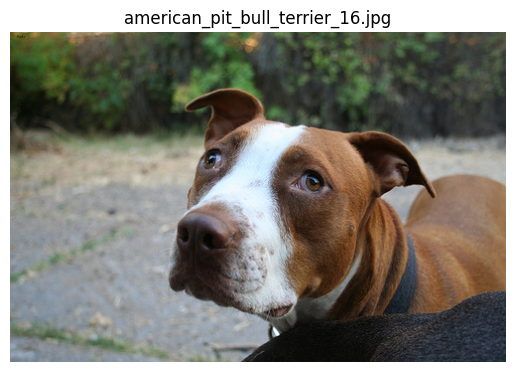

In [ ]:
sample = all_images[0]
img = image.imread(sample)
plt.imshow(img)
plt.title(sample.split("/")[-1])
plt.axis('off')
plt.show()

In [ ]:
image_names = [os.path.basename(file) for file in glob.glob(os.path.join(path, '*.jpg'))]

In [ ]:
labels = [' '.join(name.split('_')[:-1]) for name in image_names]

In [ ]:
def label_encode(label):
    if label == 'Abyssinian': return 0
    elif label == 'Bengal': return 1
    elif label == 'Birman': return 2
    elif label == 'Bombay': return 3
    elif label == 'British Shorthair': return 4
    elif label == 'Egyptian Mau': return 5
    elif label == 'american bulldog': return 6
    elif label == 'american pit bull terrier': return 7
    elif label == 'basset hound': return 8
    elif label == 'beagle': return 9
    elif label == 'boxer': return 10
    elif label == 'chihuahua': return 11
    elif label == 'english cocker spaniel': return 12
    elif label == 'english setter': return 13
    elif label == 'german shorthaired': return 14
    elif label == 'great pyrenees': return 15
    elif label == 'havanese': return 16
    elif label == 'japanese chin': return 17
    elif label == 'keeshond': return 18
    elif label == 'leonberger': return 19
    elif label == 'Maine Coon': return 20
    elif label == 'miniature pinscher': return 21
    elif label == 'newfoundland': return 22
    elif label == 'Persian': return 23
    elif label == 'pomeranian': return 24
    elif label == 'pug': return 25
    elif label == 'Ragdoll': return 26
    elif label == 'Russian Blue': return 27
    elif label == 'saint bernard': return 28
    elif label == 'samoyed': return 29
    elif label == 'scottish terrier': return 30
    elif label == 'shiba inu': return 31
    elif label == 'Siamese': return 32
    elif label == 'Sphynx': return 33
    elif label == 'staffordshire bull terrier': return 34
    elif label == 'wheaten terrier': return 35
    elif label == 'yorkshire terrier': return 36
    else: return None

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [ ]:
features = []
labels = []
IMAGE_SIZE = (224, 224)

for name in image_names:
    label = ' '.join(name.split('_')[:-1])
    label_encoded = label_encode(label)
    if label_encoded is not None:
        img = load_img(os.path.join(path, name))
        img = tf.image.resize_with_pad(img_to_array(img, dtype='uint8'), *IMAGE_SIZE).numpy().astype('uint8')
        image = np.array(img)
        features.append(image)
        labels.append(label_encoded)

In [ ]:
features_array = np.array(features)
labels_array = np.array(labels)

In [ ]:
labels_one_hot = pd.get_dummies(labels_array)

In [ ]:
from sklearn.model_selection import train_test_split

# Train 60% + val = 20% and Test: 20%
X_train, X_test, y_train, y_test = train_test_split(features_array, labels_one_hot, test_size=0.2, random_state=42)

# 80%
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1)

In [ ]:
data_augmentation = Sequential([RandomFlip("horizontal_and_vertical"), RandomRotation(0.2)])
prediction_layers = Dense(37, activation='softmax')

resnet_model = ResNet50(include_top=False, pooling='avg', weights='imagenet')
resnet_model.trainable = False
preprocess_input = pp_i

# Build model
inputs = Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = resnet_model(x, training=False)
x = Dropout(0.2)(x)
outputs = prediction_layers(x)
model = Model(inputs, outputs)

In [ ]:
model.compile(optimizer=Adam(), loss=CategoricalCrossentropy(), metrics=['accuracy'])

In [ ]:
model_history = model.fit(x=X_train, y=y_train, validation_data=(X_val, y_val), epochs=10)

Epoch 1/10


I0000 00:00:1774952194.640075     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


139/139 ━━━━━━━━━━━━━━━━━━━━ 39s 201ms/step - accuracy: 0.2649 - loss: 2.8521 - val_accuracy: 0.7835 - val_loss: 0.7129
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 25s 183ms/step - accuracy: 0.7100 - loss: 0.9707 - val_accuracy: 0.8478 - val_loss: 0.4723
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 25s 180ms/step - accuracy: 0.7870 - loss: 0.6800 - val_accuracy: 0.8701 - val_loss: 0.4228
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 24s 176ms/step - accuracy: 0.7954 - loss: 0.6415 - val_accuracy: 0.8775 - val_loss: 0.3985
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 25s 179ms/step - accuracy: 0.8077 - loss: 0.5955 - val_accuracy: 0.8890 - val_loss: 0.3691
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 25s 179ms/step - accuracy: 0.8412 - loss: 0.5075 - val_accuracy: 0.8701 - val_loss: 0.4112
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 25s 177ms/step - accuracy: 0.8418 - loss: 0.4922 - val_accuracy: 0.8755 - val_loss: 0.3702
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 25s 178ms/step - accuracy: 0.8532 - loss: 0.4620 - val

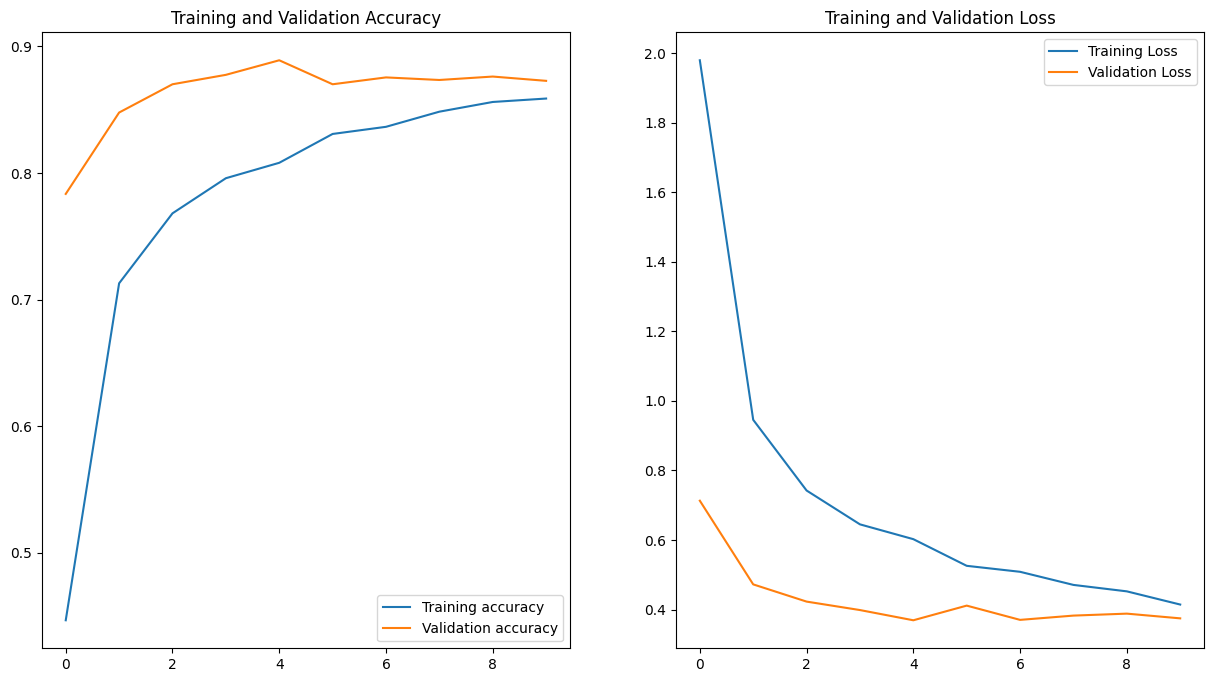

In [ ]:
acc = model_history.history['accuracy']
val_acc = model_history.history['val_accuracy']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']

epochs_range = range(10)
plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training accuracy')
plt.plot(epochs_range, val_acc, label='Validation accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
model.evaluate(X_test, y_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - accuracy: 0.8994 - loss: 0.3135


[0.331648051738739, 0.8971583247184753]

In [ ]:
y_pred = model.predict(X_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 160ms/step


In [ ]:
y_pred

array([[5.7481120e-10, 6.0045258e-10, 9.9505527e-08, ..., 3.1479636e-10,
        3.1199758e-07, 1.6390257e-12],
       [2.9912334e-07, 3.4650748e-06, 2.8569357e-08, ..., 5.5475632e-04,
        4.1508986e-08, 9.7937072e-07],
       [2.4363898e-09, 3.7443453e-09, 1.7017148e-05, ..., 9.6348529e-10,
        3.5528359e-05, 9.6290441e-11],
       ...,
       [6.4544192e-10, 1.3633768e-11, 5.5624002e-07, ..., 4.3733112e-15,
        5.1776011e-11, 9.7197814e-12],
       [1.2365739e-07, 2.2725917e-06, 3.9119541e-07, ..., 7.6232282e-05,
        4.1497415e-06, 9.9808108e-09],
       [3.5562264e-06, 2.6523372e-10, 9.5213635e-04, ..., 3.1683559e-08,
        2.6108955e-08, 3.1301552e-11]], dtype=float32)